Dataset Shape: (8469, 17)


/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Logistic Regression Accuracy:
20.25 %

Random Forest Accuracy:
19.24 %

SVM Accuracy:
20.01 %

Best Model: Logistic Regression

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.19      0.18       327
Cancellation request       0.18      0.18      0.18       339
     Product inquiry       0.21      0.24      0.23       328
      Refund request       0.22      0.20      0.21       351
     Technical issue       0.22      0.20      0.21       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



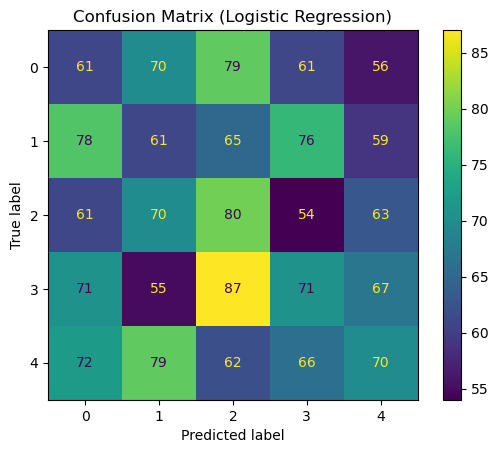

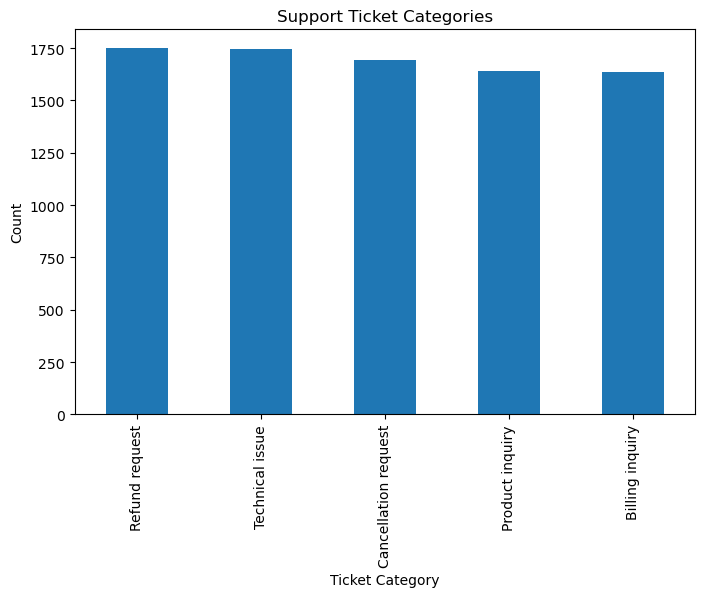

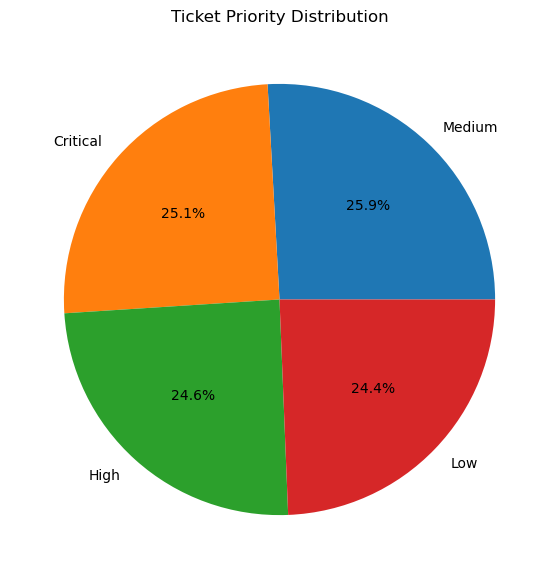


Predicted Category:
Product inquiry
Priority: Medium


In [12]:
import zipfile
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================
# NLTK DOWNLOAD
# =======================

# ==========================
# EXTRACT ZIP FILE
# ==========================

with zipfile.ZipFile(
    "customer_support_tickets.csv.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("dataset")

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv(
    "dataset/customer_support_tickets.csv"
)

print("Dataset Shape:", df.shape)

# ==========================
# REQUIRED COLUMNS
# ==========================

df = df[
    [
        "Ticket Description",
        "Ticket Type",
        "Ticket Priority"
    ]
]

df.dropna(inplace=True)

# ==========================
# TEXT CLEANING
# ==========================

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    text = " ".join(words)

    return text

df["clean_text"] = df[
    "Ticket Description"
].apply(clean_text)

# ==========================
# FEATURES & LABELS
# ==========================

X = df["clean_text"]

y = df["Ticket Type"]

# ==========================
# TF-IDF
# ==========================

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(X)

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# LOGISTIC REGRESSION
# ==========================

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear"
)

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(
    X_test
)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("\nLogistic Regression Accuracy:")
print(round(lr_accuracy * 100, 2), "%")

# ==========================
# RANDOM FOREST
# ==========================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\nRandom Forest Accuracy:")
print(round(rf_accuracy * 100, 2), "%")

# ==========================
# SVM
# ==========================

svm_model = LinearSVC()

svm_model.fit(
    X_train,
    y_train
)

svm_predictions = svm_model.predict(
    X_test
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print("\nSVM Accuracy:")
print(round(svm_accuracy * 100, 2), "%")

# ==========================
# BEST MODEL
# ==========================

accuracies = {
    "Logistic Regression": lr_accuracy,
    "Random Forest": rf_accuracy,
    "SVM": svm_accuracy
}

best_model_name = max(
    accuracies,
    key=accuracies.get
)

print("\nBest Model:", best_model_name)

if best_model_name == "Logistic Regression":

    best_model = lr_model
    best_predictions = lr_predictions

elif best_model_name == "Random Forest":

    best_model = rf_model
    best_predictions = rf_predictions

else:

    best_model = svm_model
    best_predictions = svm_predictions

# ==========================
# CLASSIFICATION REPORT
# ==========================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        best_predictions
    )
)

# ==========================
# CONFUSION MATRIX
# ==========================

cm = confusion_matrix(
    y_test,
    best_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    f"Confusion Matrix ({best_model_name})"
)

plt.show()

# ==========================
# GRAPH 1
# ==========================

plt.figure(figsize=(8,5))

df["Ticket Type"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Support Ticket Categories"
)

plt.xlabel(
    "Ticket Category"
)

plt.ylabel(
    "Count"
)

plt.show()

# ==========================
# GRAPH 2
# ==========================

plt.figure(figsize=(7,7))

df["Ticket Priority"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title(
    "Ticket Priority Distribution"
)

plt.show()

# ==========================
# TEST NEW TICKET
# ==========================

new_ticket = [
    "My payment failed and money was deducted twice"
]

new_ticket_vector = vectorizer.transform(
    new_ticket
)

predicted_category = best_model.predict(
    new_ticket_vector
)

print("\nPredicted Category:")
print(predicted_category[0])

# ==========================
# PRIORITY LOGIC
# ==========================

high_priority = [
    "Billing inquiry",
    "Technical issue"
]

medium_priority = [
    "Product inquiry"
]

if predicted_category[0] in high_priority:

    print("Priority: High")

elif predicted_category[0] in medium_priority:

    print("Priority: Medium")

else:

    print("Priority: Low")